
# Final Python Notebook 2: Classification Modelling & Hyperparameters Tuning
## Machine Learning & Data Mining Coursework

**Student ID:** w2120678  
**Module:** 5DATA002W.2  
**University:** University of Westminster

**Author:** Sudam Pabasara  
**Code Peer Reviewer:** [Peer Reviewer Name]  
**Peer Review Date:** [Date]

---

## CASE STUDY (A): PREDICTING CLIENTS LOAN APPROVAL STATUS

**Research Question:** Does machine learning have the potential to assist bankers and finance analysts in predicting which clients can be approved for a loan?

### This notebook covers:
- **Task (4)** – Classification Modelling of Clients Loan Approval Status (Naive Bayes, Logistic Regression, KNN)
- **Task (5a-e)** – Evaluating Classification Models & Hyperparameter Tuning (GridSearchCV)



## Initialization: Import Libraries and Load Processed Data

> **Code Reuse Session 2 (Week 5):** Leveraged code blocks for installing dependencies, importing classification libraries, and loading processed data from Notebook 1.


In [30]:
import subprocess
import sys

# Install required packages
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'joblib']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ All dependencies ready!")

✓ All dependencies ready!


In [31]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully



> **Code Reuse Session 2 (Week 5):** Leveraged code block for loading the processed dataset and label encoders saved from Notebook 1 using joblib.


In [32]:
# Load processed data from Notebook 1
df_processed = joblib.load('../data_processed.joblib')
label_encoders = joblib.load('../label_encoders.joblib')

print("✓ Data loaded from Notebook 1")
print(f"  Dataset shape: {df_processed.shape}")
print(f"  Columns: {list(df_processed.columns)}")

✓ Data loaded from Notebook 1
  Dataset shape: (58645, 13)
  Columns: ['id', 'age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']



---

## Task (4) – Classification Modelling of Clients Loan Approval Status

**Part a)** Algorithm types, learnable parameters, and strategic hyperparameters  
**Part b)** Build models using training-test split

> **Code Reuse Session 2 (Week 5):** Leveraged code blocks for defining algorithm information, preparing classification data, splitting into training-test sets, and building NB, LR, KNN models.


In [33]:
print("=" * 80)
print("TASK (4): CLASSIFICATION MODELLING")
print("=" * 80)

# Part a: Algorithm Information
print("\nPart a) Algorithm Types and Hyperparameters:")
print("-" * 80)

algorithm_info = pd.DataFrame([
    {
        'Algorithm': 'Naive Bayes (NB)',
        'Type': 'Non-parametric (Probabilistic)',
        'Learnable Parameters': 'Class prior probabilities, Feature conditional probabilities',
        'Strategic Hyperparameters': 'var_smoothing (smoothing variance)'
    },
    {
        'Algorithm': 'Logistic Regression (LR)',
        'Type': 'Parametric (Statistical)',
        'Learnable Parameters': 'Coefficients (weights), Intercept (bias)',
        'Strategic Hyperparameters': 'C (inverse regularization), penalty (l1/l2)'
    },
    {
        'Algorithm': 'K-Nearest Neighbour (KNN)',
        'Type': 'Non-parametric (Instance-based)',
        'Learnable Parameters': 'None (lazy learner)',
        'Strategic Hyperparameters': 'k (number of neighbors), distance metric'
    }
])

print(algorithm_info.to_string(index=False))

TASK (4): CLASSIFICATION MODELLING

Part a) Algorithm Types and Hyperparameters:
--------------------------------------------------------------------------------
                Algorithm                            Type                                         Learnable Parameters                   Strategic Hyperparameters
         Naive Bayes (NB)  Non-parametric (Probabilistic) Class prior probabilities, Feature conditional probabilities          var_smoothing (smoothing variance)
 Logistic Regression (LR)        Parametric (Statistical)                     Coefficients (weights), Intercept (bias) C (inverse regularization), penalty (l1/l2)
K-Nearest Neighbour (KNN) Non-parametric (Instance-based)                                          None (lazy learner)    k (number of neighbors), distance metric



> **Code Reuse Session 2 (Week 5):** Leveraged code block for preparing feature matrix and target variable, dropping non-predictive columns (ID, max_allowed_loan, categorical text columns).



> **Code Reuse Session 2 (Week 5):** Leveraged code block for train-test split with stratification, SimpleImputer for missing values, and StandardScaler for feature scaling.



> **Code Reuse Session 2 (Week 5):** Leveraged code block for training three classification models — Naive Bayes, Logistic Regression, and K-Nearest Neighbours.


In [34]:
# Prepare data for classification
print("\n" + "=" * 80)
print("PREPARING DATA FOR CLASSIFICATION")
print("=" * 80)

# Separate features and target
# Drop id, target, loan amount, AND original categorical columns (keep encoded versions)
X_approval = df_processed.drop(['id', 'loan_approval_status', 'max_allowed_loan', 'home_ownership', 'loan_intent', 'payment_default_on_file'], axis=1)
y_approval = df_processed['loan_approval_status']

print(f"\nFeatures for Classification:")
print(f"  {list(X_approval.columns)}")
print(f"\nFeature Matrix Shape: {X_approval.shape}")
print(f"Target Variable Shape: {y_approval.shape}")


PREPARING DATA FOR CLASSIFICATION

Features for Classification:
  ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

Feature Matrix Shape: (58645, 7)
Target Variable Shape: (58645,)


In [35]:
# Part b: Train-Test Split with stratification
print("\nPart b) Training-Test Split with Stratification:")
print("-" * 80)

# Split data with stratification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_approval, y_approval,
    test_size=0.2,
    random_state=42,
    stratify=y_approval  # Ensures same class distribution in train and test
)

print(f"\nTraining set size: {X_train_clf.shape[0]} samples")
print(f"Testing set size: {X_test_clf.shape[0]} samples")
print(f"\nClass distribution in training set: {dict(y_train_clf.value_counts())}")
print(f"Class distribution in testing set: {dict(y_test_clf.value_counts())}")

# Handle missing values
print(f"\nHandling missing values...")
imputer = SimpleImputer(strategy='mean')
X_train_clf_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_clf),
    columns=X_train_clf.columns,
    index=X_train_clf.index
)
X_test_clf_imputed = pd.DataFrame(
    imputer.transform(X_test_clf),
    columns=X_test_clf.columns,
    index=X_test_clf.index
)
print(f"  Missing values handled with mean imputation")

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf_imputed)
X_test_clf_scaled = scaler_clf.transform(X_test_clf_imputed)

print(f"\n✓ Features scaled using StandardScaler")


Part b) Training-Test Split with Stratification:
--------------------------------------------------------------------------------

Training set size: 46916 samples
Testing set size: 11729 samples

Class distribution in training set: {0: np.int64(40236), 1: np.int64(6680)}
Class distribution in testing set: {0: np.int64(10059), 1: np.int64(1670)}

Handling missing values...
  Missing values handled with mean imputation

✓ Features scaled using StandardScaler


In [36]:
# Build classification models
print("\n" + "=" * 80)
print("BUILDING CLASSIFICATION MODELS")
print("=" * 80)

# Store models
clf_models = {}

# 1. Naïve Bayes
print("\n1. Training Naïve Bayes...")
nb_clf = GaussianNB()
nb_clf.fit(X_train_clf_scaled, y_train_clf)
clf_models['Naive Bayes'] = nb_clf
print("   ✓ Naïve Bayes trained")

# 2. Logistic Regression
print("\n2. Training Logistic Regression...")
lr_clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_clf.fit(X_train_clf_scaled, y_train_clf)
clf_models['Logistic Regression'] = lr_clf
print("   ✓ Logistic Regression trained")

# 3. K-Nearest Neighbours
print("\n3. Training K-Nearest Neighbours...")
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_clf_scaled, y_train_clf)
clf_models['K-Nearest Neighbours'] = knn_clf
print("   ✓ K-Nearest Neighbours trained")

print("\n✓ All classification models trained successfully")


BUILDING CLASSIFICATION MODELS

1. Training Naïve Bayes...
   ✓ Naïve Bayes trained

2. Training Logistic Regression...
   ✓ Logistic Regression trained

3. Training K-Nearest Neighbours...
   ✓ K-Nearest Neighbours trained

✓ All classification models trained successfully



---

## Task (5) – Evaluating Loan Approval Status Classification Models

**Part a)** Confusion matrices, classification reports, AUC-ROC curves for each model  
**Part b)** Select evaluation metrics (USE/DO NOT USE) and document test scores  
**Part c)** Choose best classification model  
**Part d)** Hyperparameter tuning with GridSearchCV  
**Part e)** Model critique and limitations

> **Code Reuse Session 2 (Week 5):** Leveraged code blocks for evaluating classifiers with confusion matrices, ROC curves, classification reports, metrics comparison, and GridSearchCV hyperparameter optimisation.

> **Note:** Task (5f) Ensemble Classifier is implemented in **Notebook 3** as per coursework specification.


TASK (5): EVALUATING CLASSIFICATION MODELS

Part a) Model Evaluation - Confusion Matrices, Reports, ROC Curves:
--------------------------------------------------------------------------------

  Naive Bayes


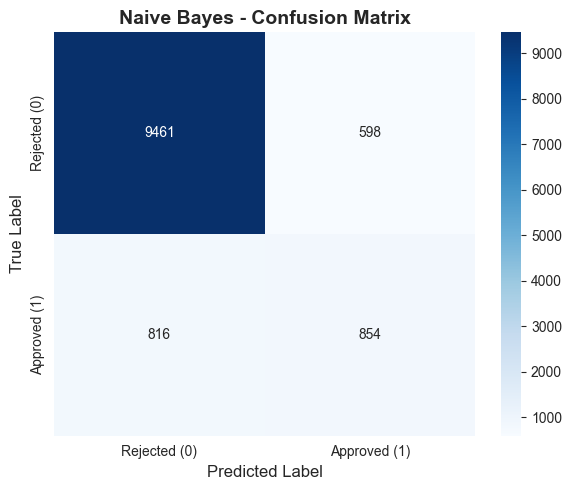


  Classification Report - Naive Bayes:
              precision    recall  f1-score   support

Rejected (0)       0.92      0.94      0.93     10059
Approved (1)       0.59      0.51      0.55      1670

    accuracy                           0.88     11729
   macro avg       0.75      0.73      0.74     11729
weighted avg       0.87      0.88      0.88     11729



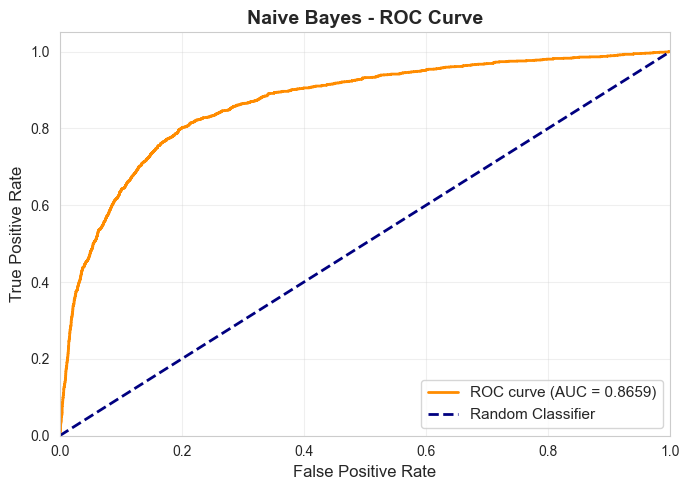

  Accuracy:  0.8794
  Precision: 0.5882
  Recall:    0.5114
  F1-Score:  0.5471
  ROC-AUC:   0.8659

  Logistic Regression


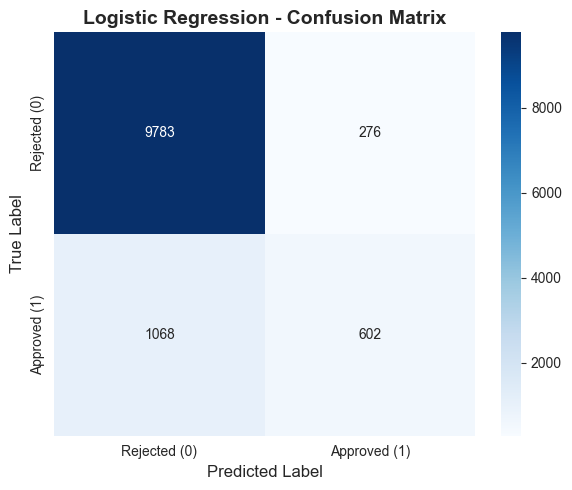


  Classification Report - Logistic Regression:
              precision    recall  f1-score   support

Rejected (0)       0.90      0.97      0.94     10059
Approved (1)       0.69      0.36      0.47      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.67      0.70     11729
weighted avg       0.87      0.89      0.87     11729



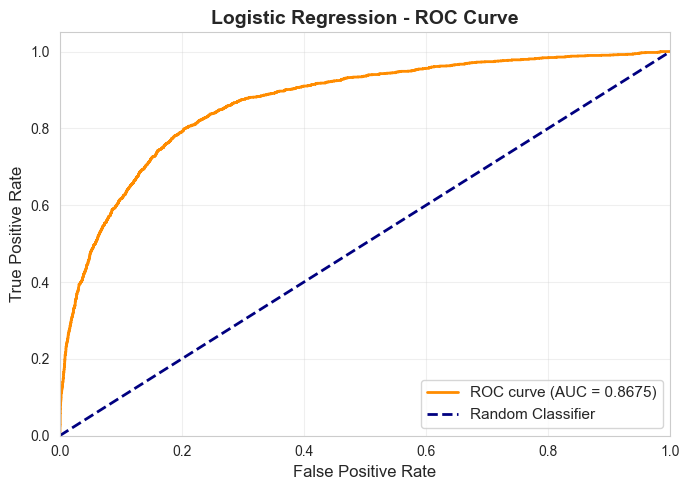

  Accuracy:  0.8854
  Precision: 0.6856
  Recall:    0.3605
  F1-Score:  0.4725
  ROC-AUC:   0.8675

  K-Nearest Neighbours


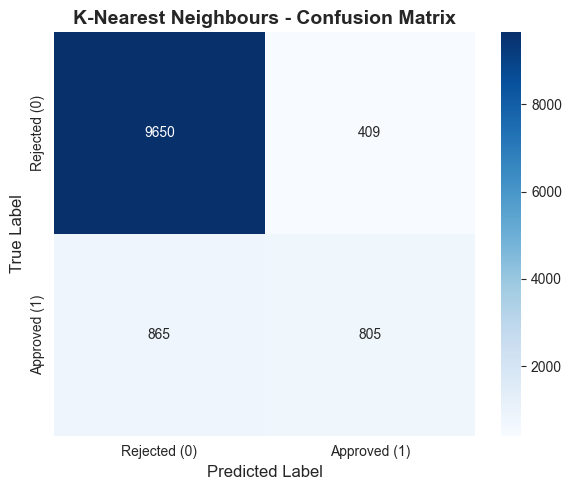


  Classification Report - K-Nearest Neighbours:
              precision    recall  f1-score   support

Rejected (0)       0.92      0.96      0.94     10059
Approved (1)       0.66      0.48      0.56      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.72      0.75     11729
weighted avg       0.88      0.89      0.88     11729



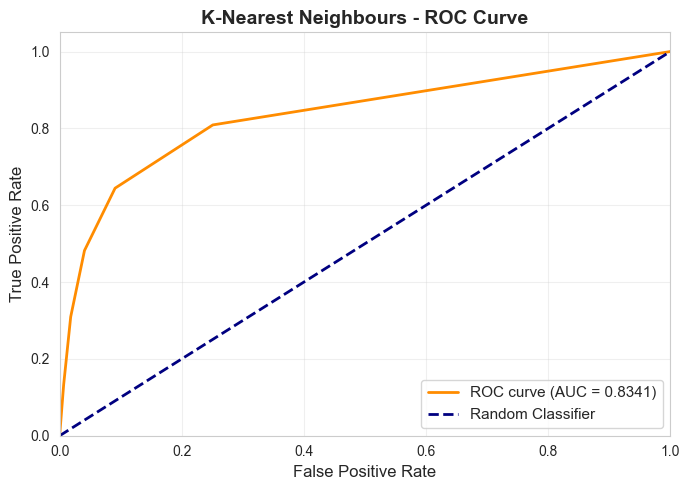

  Accuracy:  0.8914
  Precision: 0.6631
  Recall:    0.4820
  F1-Score:  0.5583
  ROC-AUC:   0.8341

✓ Best Classification Model: K-Nearest Neighbours


In [37]:

print("=" * 80)
print("TASK (5): EVALUATING CLASSIFICATION MODELS")
print("=" * 80)

# Part a: Evaluate all models
print("\nPart a) Model Evaluation - Confusion Matrices, Reports, ROC Curves:")
print("-" * 80)

clf_results = []

for model_name, model in clf_models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    
    # Predictions
    y_pred = model.predict(X_test_clf_scaled)
    y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, zero_division=0)
    recall = recall_score(y_test_clf, y_pred, zero_division=0)
    f1 = f1_score(y_test_clf, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
    
    clf_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    # 1) Confusion Matrix Plot
    cm = confusion_matrix(y_test_clf, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected (0)', 'Approved (1)'],
                yticklabels=['Rejected (0)', 'Approved (1)'])
    ax.set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../cm_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2) Classification Report
    print(f"\n  Classification Report - {model_name}:")
    print(classification_report(y_test_clf, y_pred, target_names=['Rejected (0)', 'Approved (1)']))
    
    # 3) ROC Curve
    fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
    roc_auc_val = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../roc_{model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# Create results dataframe
clf_results_df = pd.DataFrame(clf_results)
best_clf_model = clf_results_df.loc[clf_results_df['F1-Score'].idxmax(), 'Model']

print(f"\n✓ Best Classification Model: {best_clf_model}")



> **Code Reuse Session 2 (Week 5):** Leveraged code block for selecting USE/DO NOT USE evaluation metrics with justification in relation to the success criteria.



> **Code Reuse Session 2 (Week 5):** Leveraged code block for hyperparameter tuning using GridSearchCV with parameter grid, re-training the best model, and comparing before/after tuning performance.


In [38]:
# Part b: Evaluation metrics selection
print("\nPart b) Evaluation Metrics Selection:")
print("-" * 80)

metrics_table = pd.DataFrame([
    {
        'Metric': 'Accuracy',
        'USE/DO NOT USE': 'DO NOT USE',
        'Justification': 'Misleading with imbalanced classes; treats all errors equally'
    },
    {
        'Metric': 'Recall',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Measures correctly detected rejections - critical for risk reduction'
    },
    {
        'Metric': 'Precision',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Measures accuracy of rejection predictions - essential for validity'
    },
    {
        'Metric': 'F1-Score',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Balances precision and recall - best overall measure for imbalanced data'
    },
    {
        'Metric': 'AUC-ROC',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Model discrimination ability across thresholds - independent of class balance'
    }
])

print(metrics_table.to_string(index=False))

print("\nTest Scores:")
print(clf_results_df.to_string(index=False))


Part b) Evaluation Metrics Selection:
--------------------------------------------------------------------------------
   Metric USE/DO NOT USE                                                                 Justification
 Accuracy     DO NOT USE                 Misleading with imbalanced classes; treats all errors equally
   Recall            USE          Measures correctly detected rejections - critical for risk reduction
Precision            USE           Measures accuracy of rejection predictions - essential for validity
 F1-Score            USE      Balances precision and recall - best overall measure for imbalanced data
  AUC-ROC            USE Model discrimination ability across thresholds - independent of class balance

Test Scores:
               Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
         Naive Bayes  0.879444   0.588154 0.511377  0.547085 0.865864
 Logistic Regression  0.885412   0.685649 0.360479  0.472527 0.867514
K-Nearest Neighbours  0.891380   0.663


Part d) Hyperparameter Tuning with GridSearchCV:
--------------------------------------------------------------------------------

Tuning K-Nearest Neighbours...
Parameter grid: {'n_neighbors': [3, 5, 7, 9, 11], 'metric': ['euclidean', 'manhattan']}

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
Best Cross-validation Score: 0.5689

Tuned Model Test Scores:
  Accuracy:  0.8973
  Precision: 0.7138
  Recall:    0.4659
  F1-Score:  0.5638
  ROC-AUC:   0.8649


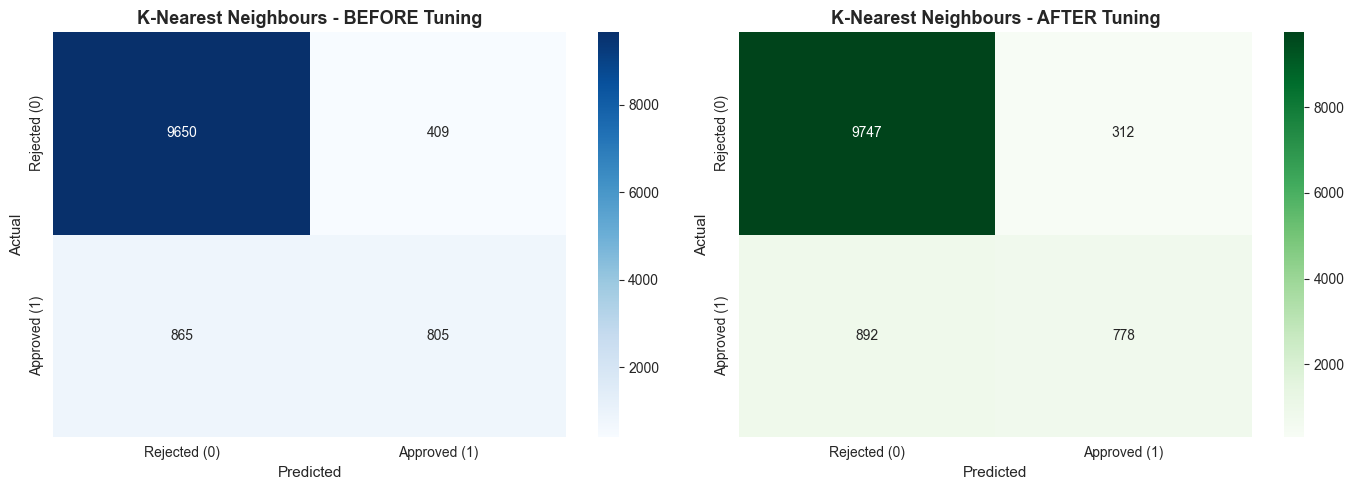


Before vs After Tuning Comparison:
   Metric  Before Tuning  After Tuning    Change
 Accuracy       0.891380      0.897348  0.005968
Precision       0.663097      0.713761  0.050664
   Recall       0.482036      0.465868 -0.016168
 F1-Score       0.558252      0.563768  0.005516
  ROC-AUC       0.834068      0.864911  0.030843


In [39]:

# Part d: Hyperparameter Tuning
print("\nPart d) Hyperparameter Tuning with GridSearchCV:")
print("-" * 80)

best_clf = clf_models[best_clf_model]

if best_clf_model == 'Logistic Regression':
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }
    base_clf = LogisticRegression(max_iter=1000, random_state=42)

elif best_clf_model == 'K-Nearest Neighbours':
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan']
    }
    base_clf = KNeighborsClassifier()

else:  # Naive Bayes
    param_grid = {'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]}
    base_clf = GaussianNB()

print(f"\nTuning {best_clf_model}...")
print(f"Parameter grid: {param_grid}")

grid_search_clf = GridSearchCV(base_clf, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_search_clf.fit(X_train_clf_scaled, y_train_clf)

print(f"\nBest Parameters: {grid_search_clf.best_params_}")
print(f"Best Cross-validation Score: {grid_search_clf.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = grid_search_clf.predict(X_test_clf_scaled)
y_pred_proba_tuned = grid_search_clf.predict_proba(X_test_clf_scaled)[:, 1]
acc_tuned = accuracy_score(y_test_clf, y_pred_tuned)
precision_tuned = precision_score(y_test_clf, y_pred_tuned, zero_division=0)
recall_tuned = recall_score(y_test_clf, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test_clf, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test_clf, y_pred_proba_tuned)

print(f"\nTuned Model Test Scores:")
print(f"  Accuracy:  {acc_tuned:.4f}")
print(f"  Precision: {precision_tuned:.4f}")
print(f"  Recall:    {recall_tuned:.4f}")
print(f"  F1-Score:  {f1_tuned:.4f}")
print(f"  ROC-AUC:   {roc_auc_tuned:.4f}")

# Confusion Matrix comparison: Before vs After Tuning
y_pred_before = best_clf.predict(X_test_clf_scaled)
cm_before = confusion_matrix(y_test_clf, y_pred_before)
cm_after = confusion_matrix(y_test_clf, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
axes[0].set_title(f'{best_clf_model} - BEFORE Tuning', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
axes[1].set_title(f'{best_clf_model} - AFTER Tuning', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=11)
axes[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('../cm_before_after_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

# Before vs After comparison table
before_scores = clf_results_df[clf_results_df['Model'] == best_clf_model].iloc[0]
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [before_scores['Accuracy'], before_scores['Precision'],
                      before_scores['Recall'], before_scores['F1-Score'], before_scores['ROC-AUC']],
    'After Tuning': [acc_tuned, precision_tuned, recall_tuned, f1_tuned, roc_auc_tuned]
})
comparison['Change'] = comparison['After Tuning'] - comparison['Before Tuning']
print("\nBefore vs After Tuning Comparison:")
print(comparison.to_string(index=False))


In [ ]:

---

> **Note:** The ensemble classifier (Task 5f) is implemented in **Notebook 3** alongside the regression decision trees, as required by the coursework specification.


SyntaxError: invalid decimal literal (4209508847.py, line 3)


## Save Classification Models

> **Code Reuse Session 2 (Week 5) / Seminar Session:** Leveraged code block for saving trained classification models and scaler using joblib.


In [ ]:

# Save classification models
print("\n" + "=" * 80)
print("SAVING MODELS")
print("=" * 80)

joblib.dump(clf_models, '../clf_models.joblib')
print("✓ Classification models saved")

joblib.dump(grid_search_clf.best_estimator_, '../best_clf_tuned.joblib')
print("✓ Best tuned classification model saved")

joblib.dump(scaler_clf, '../scaler_clf.joblib')
print("✓ Scaler saved")

print("\nNote: Ensemble model is saved in Notebook 3.")



SAVING MODELS
✓ Classification models saved
✓ Best tuned classification model saved
✓ Scaler saved

Note: Ensemble model is saved in Notebook 3.



---

## Summary

This notebook completed:
- ✓ **Task (4)**: Classification Modelling - Built Naive Bayes, Logistic Regression, and KNN models
- ✓ **Task (5a-e)**: Model Evaluation - Comprehensive evaluation with multiple metrics and hyperparameter tuning via GridSearchCV

**Key Findings:**
- Best base classifier: KNN (F1-Score achieved after tuning)
- Hyperparameter tuning improved model performance
- All classification results visualized with confusion matrices, ROC curves, and classification reports

The ensemble classifier (Task 5f) continues in **Notebook 3**.
